# Physics-Informed Neural Networks for Orbital Mechanics

## Overview

Traditional orbital simulations solve Newton's equations of motion through numerical integration. Physics-Informed Neural Networks (PINNs) provide an alternative approach by embedding the governing differential equations directly into the training process.

This project investigates whether a Physics-Informed Neural Network can learn the trajectory of a body under Newtonian gravity while satisfying the underlying laws of physics.

---

## Objectives

* Simulate a two-body orbital system using classical numerical methods.
* Develop a PINN that learns the orbital trajectory.
* Incorporate Newton's law of gravitation into the loss function.
* Compare PINN predictions against the numerical solution.
* Evaluate the accuracy and computational performance of both methods.
* Investigate the advantages and limitations of Physics-Informed Neural Networks for orbital mechanics.

---

## Newton's Law of Gravity

The motion of an object under gravity can be described by the following differential equation:

$$
\frac{d^2\vec r}{dt^2}
=
-\frac{GM}{|\vec r|^3}\vec r
$$
This equation describes how gravity causes an object's position and velocity to change over time.

---

## Variables in Newton's Law of Gravity

### $\vec r$ — Position Vector

The position vector represents the location of the satellite relative to the central body (such as Earth or the Sun).

For example, it tells us where the satellite is at any moment in time.

---

### $t$ — Time

Time represents the progression of the simulation.

As time changes, the satellite moves along its orbit.

---

### $\frac{d^2\vec r}{dt^2}$ — Acceleration

This represents how the satellite's velocity changes over time.

In simple terms, it describes how gravity changes the satellite's motion.

---

### $G$ — Gravitational Constant

This is a fixed value that determines the strength of gravity throughout the universe.

It ensures gravity behaves consistently everywhere.

---

### $M$ — Mass of the Central Body

This is the mass of the object creating the gravitational pull.

For example, if a satellite is orbiting Earth, then $M$ represents Earth's mass.

---

### $|\vec r|$ — Distance from the Central Body

This represents how far the satellite is from the center of the object it is orbiting.

As the distance increases, the strength of gravity decreases.

---

### $|\vec r|^3$ — Distance Cubed

This term determines how quickly gravity weakens as distance increases.

The farther away the satellite is, the weaker the gravitational pull becomes.

---

### $-$ (Negative Sign)

The negative sign indicates that gravity always pulls the satellite toward the central body rather than pushing it away.

---

## Why Do We Need to Solve This Equation?

Although Newton's law tells us how gravity affects an object's motion, it does not directly tell us where the satellite will be after a certain amount of time.

To determine the satellite's trajectory, we must solve this differential equation.

---

## Traditional Approach

Traditionally, orbital motion is solved using **numerical integration**.

Rather than solving the entire orbit all at once, numerical methods calculate the satellite's position and velocity over many very small time steps.

In this project, SciPy's `solve_ivp` function will be used to generate a classical numerical solution. This solution will serve as the baseline for comparison with the Physics-Informed Neural Network.

---

## Physics-Informed Neural Networks

Instead of repeatedly solving the differential equation through numerical integration, a Physics-Informed Neural Network (PINN) attempts to learn the solution directly.

Rather than being trained only on examples, the neural network is also penalized whenever its predictions violate Newton's law of gravity.

This encourages the model to produce trajectories that both fit the data and obey the underlying laws of physics.

> **Note:** For readers unfamiliar with machine learning, a **loss function** is a numerical score that measures how well a neural network is performing. During training, the model continuously adjusts its parameters to minimize this value. In a Physics-Informed Neural Network, the loss function also penalizes solutions that violate the governing laws of physics.


In [11]:
#For Arrays and math operations
import numpy as np

#Neural network framework for creating the PINN
import torch
import torch.nn as nn

#Static plots (orbits, loss, etc.)
import matplotlib.pyplot as plt

#Animating the orbit/trajectory
from matplotlib.animation import FuncAnimation

#Classical numerical ODE solver
from scipy.integrate import solve_ivp

# Interactive sliders for changing parameters
import ipywidgets as widgets
from ipywidgets import interact, interactive, FloatSlider

#Rendering animations 
from IPython.display import HTML, display

## Lock random seeds so results are reproducible on every re-run
np.random.seed(42)
torch.manual_seed(42)

#use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## Step 1: Simulating "Ground Truth" with Classical Numerical Methods

Before we teach a neural network any physics, we need something to compare it against. A trajectory we trust is correct. We'll generate this using a classical numerical IDE solver.

### From one 2nd-order equation to two 1st-order equations

Our governing equation from before is:

$$
\frac{d^2\vec r}{dt^2} = -\frac{GM}{|\vec r|^3}\vec r
$$

Solvers like the one we're using (`solve_ivp`) work with **first-order** systems, not the second-order ones. So the standard trick is to introduce velocity $\vec v$ as its own variables:

$$
\frac{d\vec r}{dt} = \vec v
$$

$$
\frac{d\vec v}{dt} = -\frac{GM}{|\vec r|^3}\vec r
$$

In plain terms: *the position changes according to the velocity, and the velocity changes according to the gravitational pull.* Together, these two simple rules are equivalent to the original equation, we've just plit "aacceleration" into two smaller, solver-friendly steps.

### What the solver actually does

Given a starting postion and velocity, `solve_ivp` takes many small time steps, and at each one it asks "given where I am and how fast I'm moving, where do I end up a tiny moment later?" Repeating this thousands of times traces out the full orbit.

This is the "Brute-force" approach. No lerning involved, just direct computation from the physics equation. It's what the PINN will later try to learn to reproduce.

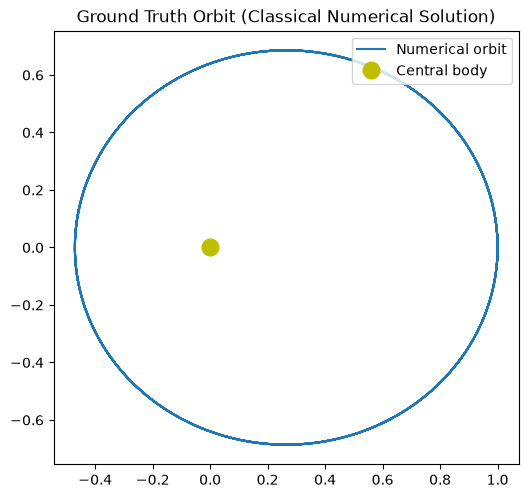

In [12]:
#Gravitational parameter
GM = 1.0

def two_body_dynamics(t, state):
    """
    state = [x, y, vx, vy]
    Returns the derivative: [vx, vy, ax, ay]
    """
    x, y, vx, vy = state
    #distance from central body
    r = np.sqrt(x**2 + y**2)  

    #Acceleration from Newton's law of gravitation
    ax = -GM * x / r**3
    ay = -GM * y / r**3

    return [vx, vy, ax, ay]

#Initial conditions for the orbit
#Starting position and velocity
initial_state = [1.0, 0.0, 0.0, 0.8]  # [x0, y0, vx0, vy0]

#Time span for the simulation
t_span = (0, 20) #from t=0 to t=20
#1000 time points for evaluation
t_eval = np.linspace(*t_span, 1000)

#solve the ODE using scipy's solve_ivp
solution = solve_ivp(
    two_body_dynamics, 
    t_span, 
    initial_state, 
    t_eval=t_eval,
    method='DOP853', #Dormand-Prince method, good for non-stiff problems
    rtol=1e-10,
    atol=1e-10
)

x_true, y_true = solution.y[0], solution.y[1]


#Sanity Check plot
plt.figure(figsize=(6, 6))
plt.plot(x_true, y_true, label="Numerical orbit")
plt.plot(0, 0, "yo", markersize=12, label="Central body")
plt.gca().set_aspect("equal")
plt.legend(loc="upper right")
plt.title("Ground Truth Orbit (Classical Numerical Solution)")
plt.show()



## Step 2: What is a Physics-Informed Neural network?

### The traditional way neural networks learn

A normal neural network learn purely from data. Show it thousands of input/output examples, and it gradually adjusts its internal weights until its predictions match the examples closely. It has no built-in understanding of *why* those examples look the way they do, it's just pattern matching.

